<a href="https://colab.research.google.com/github/abeeraz379/Stroke_Prediction/blob/main/Stroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder,StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor , DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.neighbors import KNeighborsClassifier

# Load and Inspect Data

In [3]:
df =pd.read_csv("/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/02-IntroML/Week07/Data/stroke.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


In [5]:
# check The consisitancy for all columns value
for col in df.columns:
  print(col)
  print(df[col].value_counts())

id
id
5731     1
20463    1
7218     1
37237    1
26777    1
        ..
57210    1
24257    1
24905    1
59200    1
77       1
Name: count, Length: 1137, dtype: int64
gender
gender
Female    642
Male      494
Other       1
Name: count, dtype: int64
age
age
79     26
78     24
57     24
52     23
81     22
       ..
21      7
69      7
4       6
12      6
*82     1
Name: count, Length: 84, dtype: int64
hypertension
hypertension
0    1002
1     135
Name: count, dtype: int64
heart_disease
heart_disease
0    1059
1      78
Name: count, dtype: int64
ever_married
ever_married
Yes    769
No     368
Name: count, dtype: int64
work_type
work_type
Private          672
Self-employed    174
children         147
Govt_job         142
Never_worked       2
Name: count, dtype: int64
Residence_type
Residence_type
Urban    587
Rural    550
Name: count, dtype: int64
avg_glucose_level
avg_glucose_level
92.14     3
115.52    2
203.81    2
84.04     2
74.96     2
         ..
190.13    1
232.81    1
100.09    

In [6]:
df['age'].replace('*82','82',inplace=True)
df['age'].value_counts()

/tmp/ipykernel_13755/583709423.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].replace('*82','82',inplace=True)


,count
age,
79,26
78,24
57,24
52,23
81,22
...,...
46,7
7,7
21,7


In [7]:
df['age']=df['age'].astype(int)
df['age']

,age
0,31
1,13
2,18
3,65
4,4
...,...
1132,1
1133,6
1134,81
1135,81


In [8]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [9]:
df.duplicated().sum()

np.int64(0)

# Explore Data

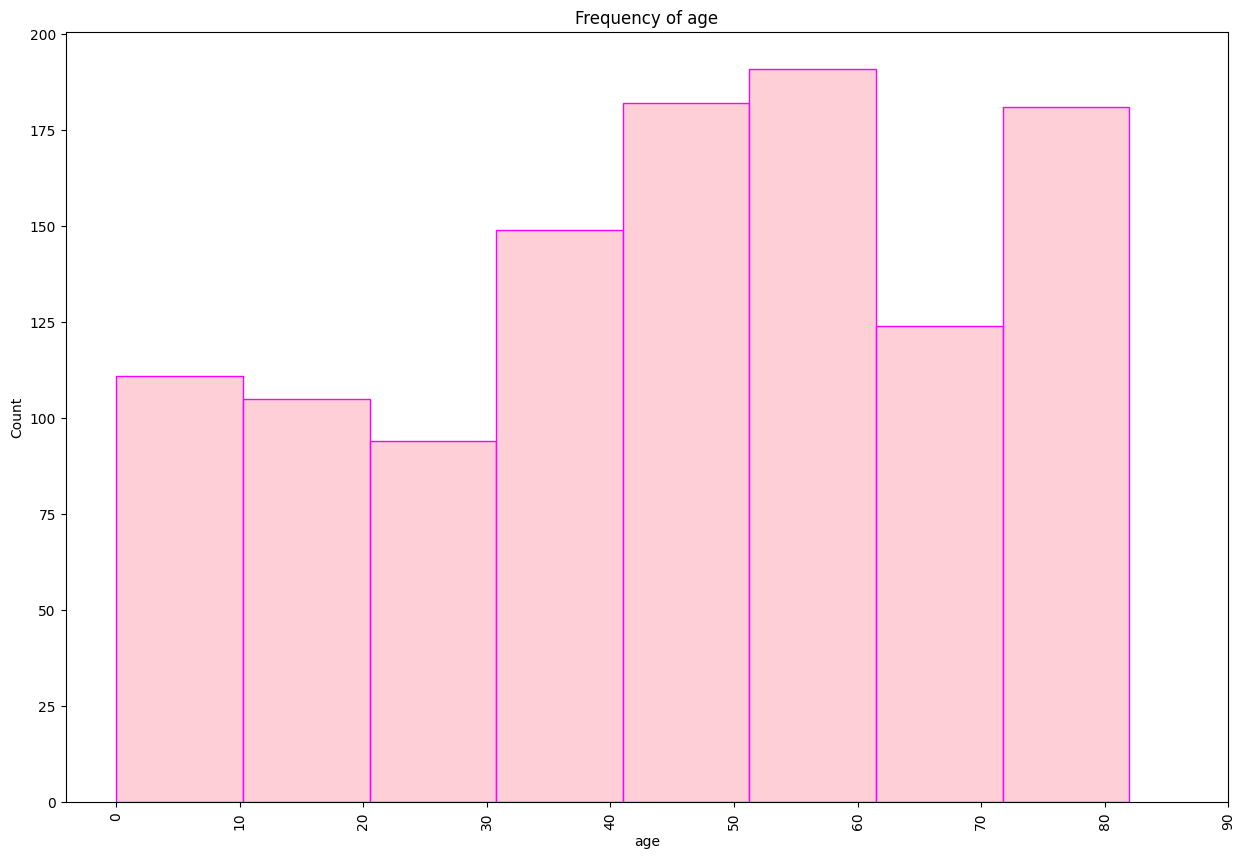

In [10]:
# make histogram for age
fig,ax=plt.subplots(figsize=(15,10))
ax =sns.histplot(data=df, x='age',binwidth=10,color='Pink',edgecolor='#FF00FF')
ax.set_title('Frequency of age')
ticks = np.arange(0, df['age'].max() + 10, 10)
ax.set_xticks(ticks)
ax.set_xticklabels(ticks, rotation=90);


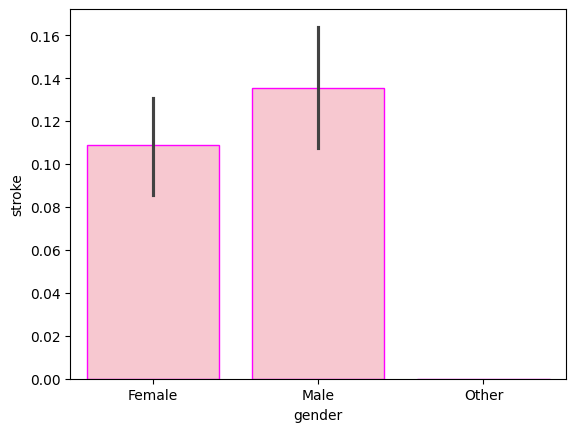

In [11]:
ax =sns.barplot(data=df, x='gender',y='stroke',color='Pink',edgecolor='#FF00FF')

# Split Data

In [12]:
# determine the target and features
y=df['stroke']
X=df.drop(columns=['id','stroke'])

In [13]:
x_train,x_test,y_train,y_test=train_test_split(X,y,random_state=42)

# Column Transformer

In [14]:
# PREPROCESSING PIPELINE FOR NUMERIC DATA

# Save list of column names

num_cols = x_train.select_dtypes("number").columns

print("Numeric Columns:", num_cols)

# instantiate preprocessors

impute_median = SimpleImputer(strategy='median')

scaler = StandardScaler()

# Make a numeric preprocessing pipeline

num_pipe = make_pipeline(impute_median, scaler)

num_tuple=('numeric',num_pipe,num_cols)
num_tuple

Numeric Columns: Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')


('numeric',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object'))

In [15]:
# PREPROCESSING PIPELINE FOR ONE-HOT-ENCODED DATA

# Save list of column names

ohe_cols = x_train.select_dtypes('object').columns

print("OneHotEncoder Columns:", ohe_cols)

# Instantiate the individual preprocessors

impute_na = SimpleImputer(strategy='constant', fill_value = "NA")

ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Make pipeline with imputer and encoder

ohe_pipe = make_pipeline(impute_na, ohe_encoder)

cat_tuple=('categorical',ohe_pipe,ohe_cols)
cat_tuple

OneHotEncoder Columns: Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


('categorical',
 Pipeline(steps=[('simpleimputer',
                  SimpleImputer(fill_value='NA', strategy='constant')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['gender', 'ever_married', 'work_type', 'Residence_type',
        'smoking_status'],
       dtype='object'))

In [16]:
col_transformer=ColumnTransformer(
    [
        num_tuple,
        cat_tuple],
    verbose_feature_names_out=False)

In [17]:
col_transformer.fit(x_train)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='NA',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [18]:
x_train_transformed=col_transformer.transform(x_train)
x_test_transformed=col_transformer.transform(x_test)

# Evaluate Function

In [19]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False, verbose=True):

    report = classification_report(y_true, y_pred)

    header = "-" * 50
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)

    fig, axes = plt.subplots(ncols=2, figsize=figsize)

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=None,
        cmap='gist_gray',
        colorbar=colorbar,
        ax=axes[0]
    )
    axes[0].set_title("Raw Counts")

    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred,
        normalize=normalize,
        cmap=cmap,
        colorbar=colorbar,
        ax=axes[1]
    )
    axes[1].set_title("Normalized Confusion Matrix")

    fig.tight_layout()
    plt.show()

    if output_dict:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict

In [20]:
def evaluate_classification(model, x_train, y_train, x_test, y_test,
figsize=(6,4), normalize='true', output_dict = False,
cmap_train='Blues', cmap_test="Reds",colorbar=False ,  verbose=True):

  # Get predictions for training data
  y_train_pred = model.predict(x_train_transformed)
 # Call the helper function to obtain regression metrics for training data
  results_train = classification_metrics(y_train, y_train_pred, verbose =verbose,output_dict=True, figsize=figsize,colorbar=colorbar, cmap=cmap_train,label='Training Data')
  print()
# Get predictions for test data
  y_test_pred = model.predict(x_test_transformed)
# Call the helper function to obtain regression metrics for test data
  results_test = classification_metrics(y_test, y_test_pred, verbose = verbose,output_dict=True, figsize=figsize,colorbar=colorbar, cmap=cmap_test,label='Test Data' )
  if output_dict == True:

# Store results in a dataframe if ouput_frame is True
    results_dict = {'train':results_train,'test': results_test}
    return results_dict

# Build DecisionTreeClassifier Model

In [21]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train_transformed, y_train)

DecisionTreeClassifier(random_state=42)

--------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



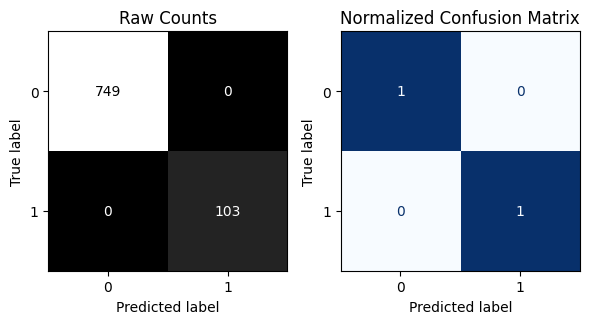


--------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       251
           1       0.29      0.24      0.26        34

    accuracy                           0.84       285
   macro avg       0.59      0.58      0.58       285
weighted avg       0.83      0.84      0.83       285



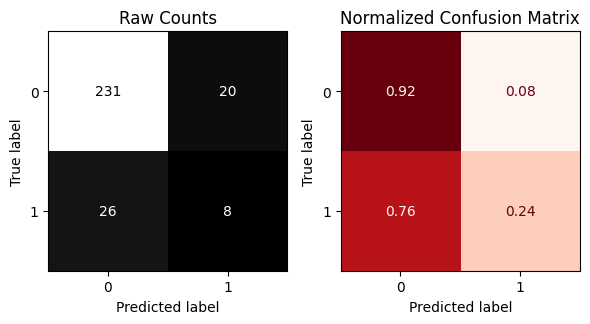

In [22]:
# test
results = evaluate_classification(model, x_train_transformed, y_train, x_test_transformed, y_test,output_dict=True)


1. What was the overall accuracy of the model? (How would you describe the default model's performance considering the accuracy and class balance?)

- 0.84

2. Using this model, what percentage of the predictions would cause an unnecessary stroke alert for a patient who did not end up having a stroke? (A false positive)?

- 0.08

3. Using this model, what percentage of the predictions would miss warning a patient who ended up having a stroke (False Negatives)

- 0.76

4. Considering that this dataset is used to identify strokes, which metric do you think would be important to optimize? Why?
- macro avg , cause it low and this refer that data is  imbalanced and all of the result for class 1 is low

# Logistic Regression

In [23]:

logreg = LogisticRegression(random_state=42)
logreg.fit(x_train_transformed, y_train)

LogisticRegression(random_state=42)

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
y_test_pred = logreg.predict(x_test_transformed)
print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.29      0.06      0.10        34

    accuracy                           0.87       285
   macro avg       0.59      0.52      0.51       285
weighted avg       0.81      0.87      0.83       285

[[246   5]
 [ 32   2]]


#  Tuned Logistic Regression

In [25]:
logreg.get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 100,
 'multi_class': 'deprecated',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [54]:
# Defining the Param Grid
params={'C': [0.0001, 0.001,0.01, 0.1, 1, 10, 100, 1000]}
# Instantiate GS with scoring = 'recall_macro' and return_train_score = True
gs = GridSearchCV(logreg, params, verbose=True, n_jobs =- 1,
return_train_score=True, scoring='recall_macro')
# Fit the gridsearch on the training data
gs.fit(x_train_transformed, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             return_train_score=True, scoring='recall_macro', verbose=True)

In [55]:
gs.best_params_

{'C': 10}

In [ ]:
cv_results = pd.DataFrame(gs.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,...,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score
0,0.006913,0.001108,0.004318,0.000385,0.0001,{'C': 0.0001},0.500000,0.500000,0.500000,0.500000,...,0.500000,0.000000,6,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000
1,0.006718,0.000997,0.004569,0.000457,0.0010,{'C': 0.001},0.500000,0.500000,0.500000,0.500000,...,0.500000,0.000000,6,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.000000
2,0.006845,0.000844,0.004498,0.000438,0.0100,{'C': 0.01},0.500000,0.500000,0.500000,0.500000,...,0.500000,0.000000,6,0.506098,0.506098,0.506024,0.506024,0.500000,0.504849,0.002425
3,0.007305,0.000433,0.004168,0.000162,0.1000,{'C': 0.1},0.568095,0.540952,0.511667,0.540000,...,0.540324,0.017851,5,0.542937,0.572590,0.552728,0.553563,0.562907,0.556945,0.010057
4,0.010411,0.000602,0.004281,0.000117,1.0000,{'C': 1},0.558095,0.537619,0.611667,0.565000,...,0.565406,0.024825,4,0.557891,0.585040,0.567462,0.580345,0.588394,0.575826,0.011445
5,0.011924,0.002252,0.004247,0.000079,10.0000,{'C': 10},0.554762,0.534286,0.611667,0.586667,...,0.567735,0.027734,1,0.561485,0.596401,0.572651,0.578675,0.591159,0.580074,0.012586
6,0.011562,0.001158,0.004683,0.000145,100.0000,{'C': 100},0.554762,0.534286,0.611667,0.583333,...,0.567068,0.027308,2,0.561485,0.596401,0.572651,0.578675,0.591992,0.580241,0.012736
7,0.011717,0.001143,0.004742,0.000353,1000.0000,{'C': 1000},0.554762,0.534286,0.611667,0.583333,...,0.567068,0.027308,2,0.561485,0.596401,0.572651,0.578675,0.591992,0.580241,0.012736


In [ ]:
# Making a dataframe with cv_results
cv_results = pd.DataFrame(gs.cv_results_)
# Save the train/test scores + value for C
scores =cv_results[['param_C', 'mean_train_score' , 'mean_test_score']]
scores = scores.set_index('param_C')
scores

,mean_train_score,mean_test_score
param_C,,
0.0001,0.500000,0.500000
0.0010,0.500000,0.500000
0.0100,0.504849,0.500000
0.1000,0.556945,0.540324
1.0000,0.575826,0.565406
10.0000,0.580074,0.567735
100.0000,0.580241,0.567068
1000.0000,0.580241,0.567068


In [60]:

params={'l1_ratio':[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],

        }

# Create and fit the gridsearch and display results
gs = GridSearchCV(logreg, params, verbose=True, n_jobs =- 1,cv=3, return_train_score=True,scoring='f1_macro',)
gs.fit(x_train_transformed, y_train)
gs.best_params_



Fitting 3 folds for each of 11 candidates, totalling 33 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


{'l1_ratio': 0}

In [61]:

logreg2 = LogisticRegression(random_state=42,C= 10, penalty='l1',solver='saga',l1_ratio= 0.1,class_weight='balanced')
logreg2.fit(x_train_transformed, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=10, class_weight='balanced', l1_ratio=0.1, penalty='l1',
                   random_state=42, solver='saga')

In [62]:
y_test_pred2 = logreg2.predict(x_test_transformed)
print(classification_report(y_test, y_test_pred2))
print(confusion_matrix(y_test, y_test_pred2))

              precision    recall  f1-score   support

           0       0.96      0.75      0.84       251
           1       0.30      0.79      0.44        34

    accuracy                           0.75       285
   macro avg       0.63      0.77      0.64       285
weighted avg       0.88      0.75      0.79       285

[[188  63]
 [  7  27]]


 The Best Tuned :
 - penalty='l1',solver='saga',l1_ratio= 0.1,class_weight='balanced'


# KNN

In [30]:
knn= KNeighborsClassifier()
knn.fit(x_train_transformed, y_train)

KNeighborsClassifier()

--------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       749
           1       0.61      0.24      0.35       103

    accuracy                           0.89       852
   macro avg       0.76      0.61      0.64       852
weighted avg       0.87      0.89      0.87       852



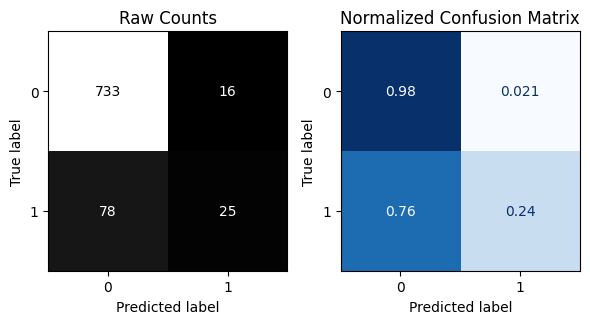


--------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       251
           1       0.22      0.06      0.09        34

    accuracy                           0.86       285
   macro avg       0.55      0.52      0.51       285
weighted avg       0.81      0.86      0.83       285



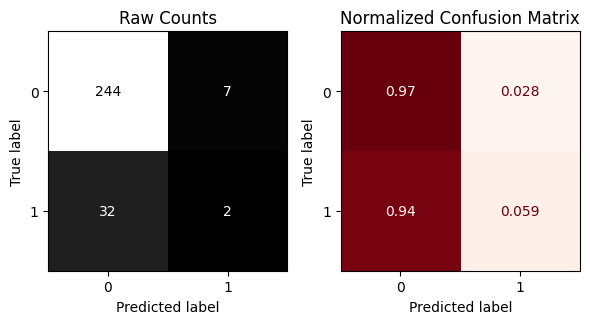

In [31]:
evaluate_classification(knn, x_train_transformed, y_train, x_test_transformed, y_test)

In [32]:
knn.get_params()

{'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform'}

# Tuned KNN

In [33]:

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21],        # k value
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': [5,10, 20, 30, 40, 50],
    'p': [1, 2, 3]
}



gs = GridSearchCV(knn, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(x_train_transformed, y_train)
print(gs.best_params_)
print(gs.best_score_)

Fitting 3 folds for each of 420 candidates, totalling 1260 fits
{'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
0.5695125653381645


In [52]:
knn2= KNeighborsClassifier(leaf_size= 20, metric='euclidean', n_neighbors= 9, p= 1, weights= 'uniform')
knn2.fit(x_train_transformed, y_train)

KNeighborsClassifier(leaf_size=20, metric='euclidean', n_neighbors=9, p=1)

--------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       749
           1       0.74      0.17      0.27       103

    accuracy                           0.89       852
   macro avg       0.82      0.58      0.61       852
weighted avg       0.88      0.89      0.86       852



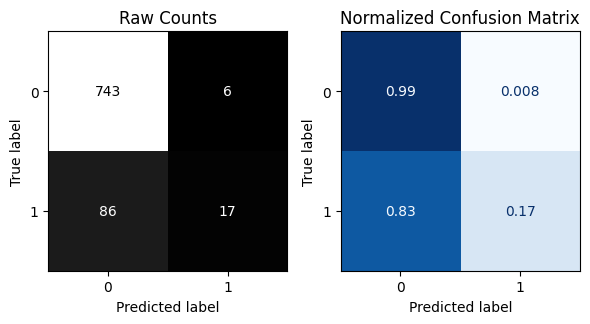


--------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.00      0.00      0.00        34

    accuracy                           0.87       285
   macro avg       0.44      0.49      0.46       285
weighted avg       0.77      0.87      0.82       285



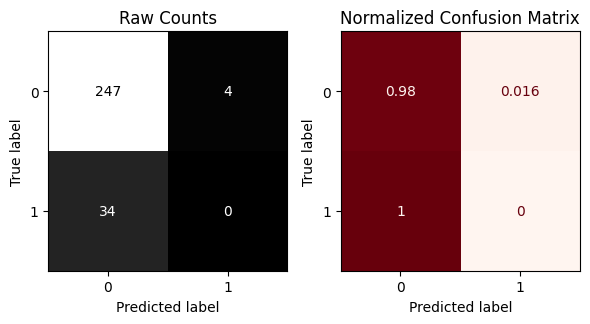

In [53]:
evaluate_classification(knn2, x_train_transformed, y_train, x_test_transformed, y_test)

 The Best Tuned :
 - 'algorithm': 'auto',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 5,
 'p': 2,
 'weights': 'uniform


# Random Forest

In [39]:
# Build random forest model
rf = RandomForestClassifier()
rf.fit(x_train_transformed, y_train)

RandomForestClassifier()

--------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       749
           1       1.00      1.00      1.00       103

    accuracy                           1.00       852
   macro avg       1.00      1.00      1.00       852
weighted avg       1.00      1.00      1.00       852



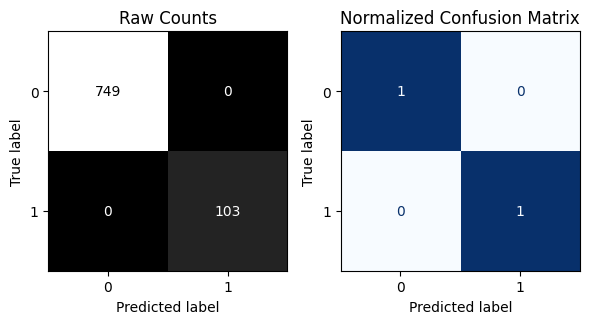


--------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.14      0.03      0.05        34

    accuracy                           0.86       285
   macro avg       0.51      0.50      0.49       285
weighted avg       0.79      0.86      0.82       285



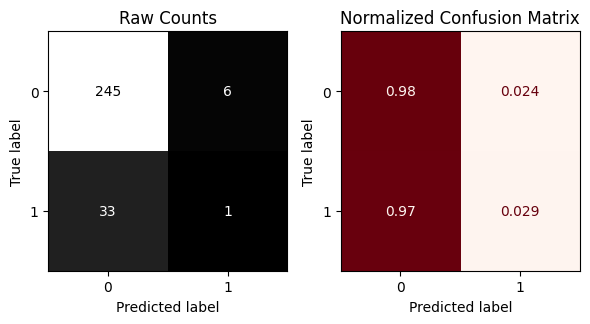

In [40]:
evaluate_classification(rf, x_train_transformed, y_train, x_test_transformed, y_test)

# Tunned Random Forest

In [41]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [42]:

param_grid = {
    'n_estimators': [50,100, 200, 300, 500,700],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

gs = GridSearchCV(rf, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
gs.fit(x_train_transformed, y_train)

print(gs.best_params_)
print(gs.best_score_)

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
{'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
0.596537394149092


In [43]:
rf2= RandomForestClassifier(bootstrap= False, max_depth=10 , min_samples_leaf= 1, min_samples_split= 5, n_estimators= 50)
rf2.fit(x_train_transformed, y_train)

RandomForestClassifier(bootstrap=False, max_depth=10, min_samples_split=5,
                       n_estimators=50)

--------------------------------------------------
 Classification Metrics: Training Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       749
           1       1.00      0.82      0.90       103

    accuracy                           0.98       852
   macro avg       0.99      0.91      0.94       852
weighted avg       0.98      0.98      0.98       852



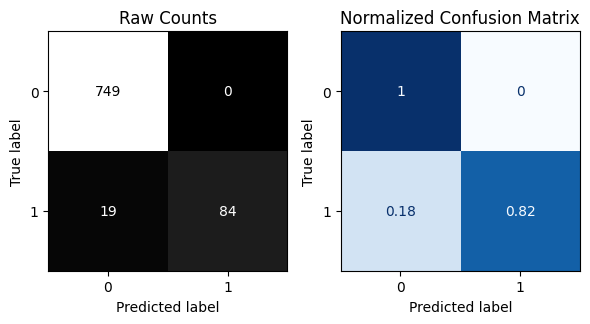


--------------------------------------------------
 Classification Metrics: Test Data
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       251
           1       0.25      0.06      0.10        34

    accuracy                           0.87       285
   macro avg       0.57      0.52      0.51       285
weighted avg       0.81      0.87      0.83       285



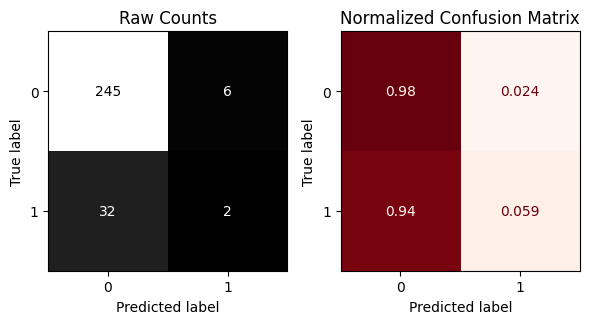

In [44]:
evaluate_classification(rf2, x_train_transformed, y_train, x_test_transformed, y_test)

#  Tuned Logistic Regression is the best performance Model , However all the models have overfitting